# From Random Walks to Brownian Motion
## Donsker's Invariance Principle

This notebook builds Brownian motion from the ground up, starting with the simplest object in probability — a random walk — and showing how a suitable rescaling produces a continuous Gaussian process in the limit.

**Roadmap:**

1. The simple symmetric random walk
2. The rescaling idea: why $1/\sqrt{N}$?
3. Donsker's theorem — statement and simulation
4. Verifying the properties of the limit (Brownian motion)
5. Beyond coin flips — universality

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
    "lines.linewidth": 1.5,
})

rng = np.random.default_rng(42)

---
# Part 1: The Simple Symmetric Random Walk

Let $X_1, X_2, \ldots$ be i.i.d. with $P(X_i = +1) = P(X_i = -1) = 1/2$. The **random walk** is

$$S_k = \sum_{i=1}^{k} X_i, \qquad S_0 = 0.$$

Key properties:
- $\mathbb{E}[S_k] = 0$ (the walk is centred)
- $\text{Var}(S_k) = k$ (variance grows linearly in time)
- Increments $S_k - S_j$ are independent of $S_j - S_i$ for $i < j < k$

Let's plot a few sample paths.

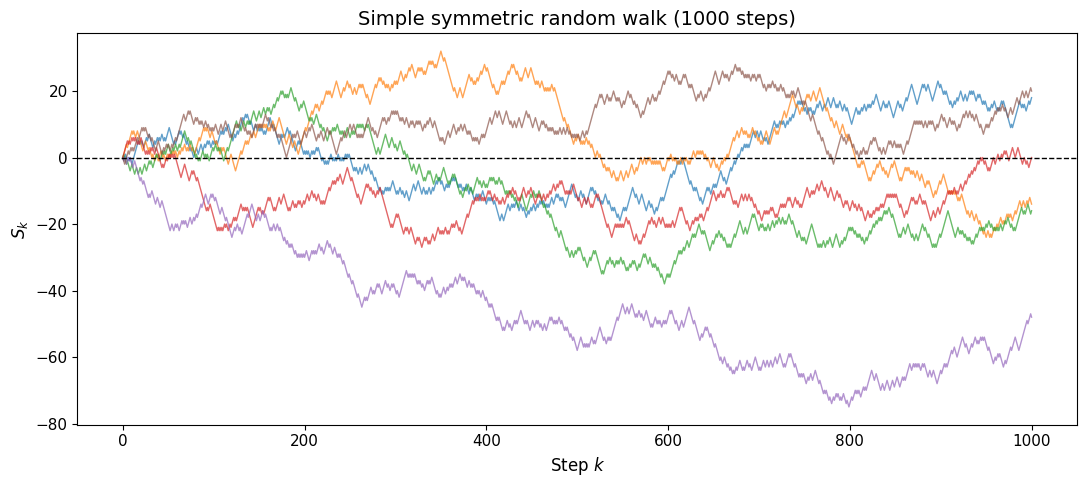

In [2]:
n_steps = 1000
n_paths = 6

fig, ax = plt.subplots(figsize=(11, 5))
for _ in range(n_paths):
    steps = rng.choice([-1, 1], size=n_steps)
    walk = np.concatenate([[0], np.cumsum(steps)])
    ax.plot(walk, alpha=0.7, lw=1)

ax.axhline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Step $k$")
ax.set_ylabel("$S_k$")
ax.set_title(f"Simple symmetric random walk ({n_steps} steps)")
plt.tight_layout()
plt.show()

### The $\sqrt{k}$ envelope

Since $\text{Var}(S_k) = k$, typical fluctuations are of order $\sqrt{k}$. Let's verify this by overlaying a $\pm 2\sqrt{k}$ band (roughly the 95% range).

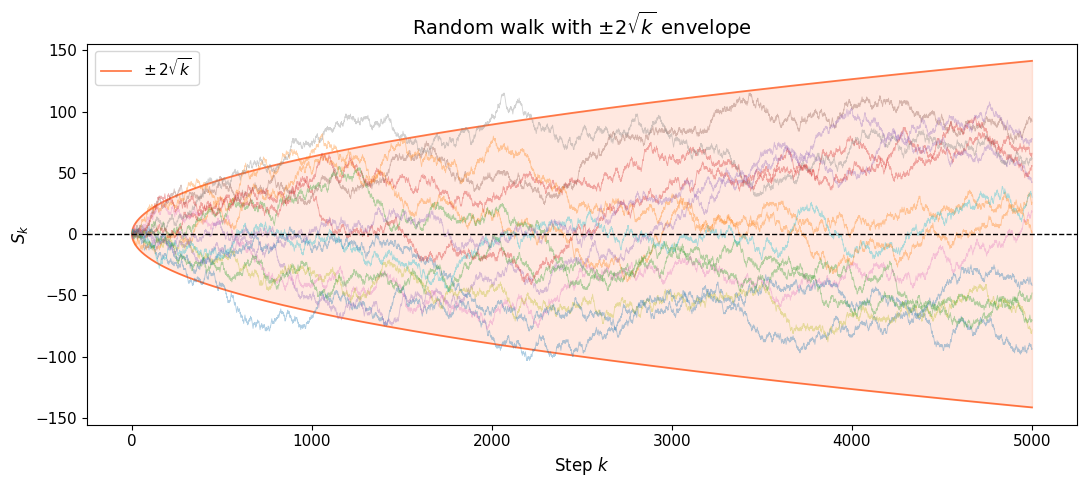

In [3]:
n_steps = 5000

fig, ax = plt.subplots(figsize=(11, 5))
ks = np.arange(0, n_steps + 1)

# Envelope
env = 2 * np.sqrt(ks)
ax.fill_between(ks, -env, env, color="orangered", alpha=0.12, zorder=1)
ax.plot(ks, env, color="orangered", lw=1.3, alpha=0.7, label=r"$\pm\, 2\sqrt{k}$", zorder=2)
ax.plot(ks, -env, color="orangered", lw=1.3, alpha=0.7, zorder=2)

for _ in range(15):
    steps = rng.choice([-1, 1], size=n_steps)
    walk = np.concatenate([[0], np.cumsum(steps)])
    ax.plot(walk, alpha=0.35, lw=0.6, zorder=3)

ax.axhline(0, color="black", ls="--", lw=1, zorder=4)
ax.set_xlabel("Step $k$")
ax.set_ylabel("$S_k$")
ax.set_title("Random walk with $\\pm 2\\sqrt{k}$ envelope")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---
# Part 2: The Rescaling Idea

The random walk $S_k$ lives on the integer lattice and takes discrete steps. To get a *continuous* process on $[0, T]$, we need to:

1. **Compress time** — cut $[0, T]$ into $N$ sub-intervals of length $\Delta = T/N$, and map step $k$ to time $k\frac{T}{N}$.
2. **Compress space** — multiply by $\sqrt{T/N}$ so the fluctuations don't blow up (recall $\text{Var}(S_N) = N$).
3. **Interpolate** — connect the dots with straight lines to get a continuous path.

This gives us the **rescaled random walk** (Donsker's construction):

$$U_{k\frac{T}{N}} = \sqrt{\frac{T}{N}}\, S_k = \sqrt{\frac{T}{N}} \sum_{i=1}^{k} X_i, \qquad k = 0, 1, \ldots, N,$$

with linear interpolation between grid points to obtain a continuous process $U^N_t$ for $t \in [0, T]$.

More simply, $U^N_t$ is the piecewise-linear function passing through the points

$$\left(\frac{kT}{N},\; \sqrt{\frac{T}{N}}\, S_k\right), \qquad k = 0, 1, \ldots, N.$$

Let's see what this looks like for increasing $N$.

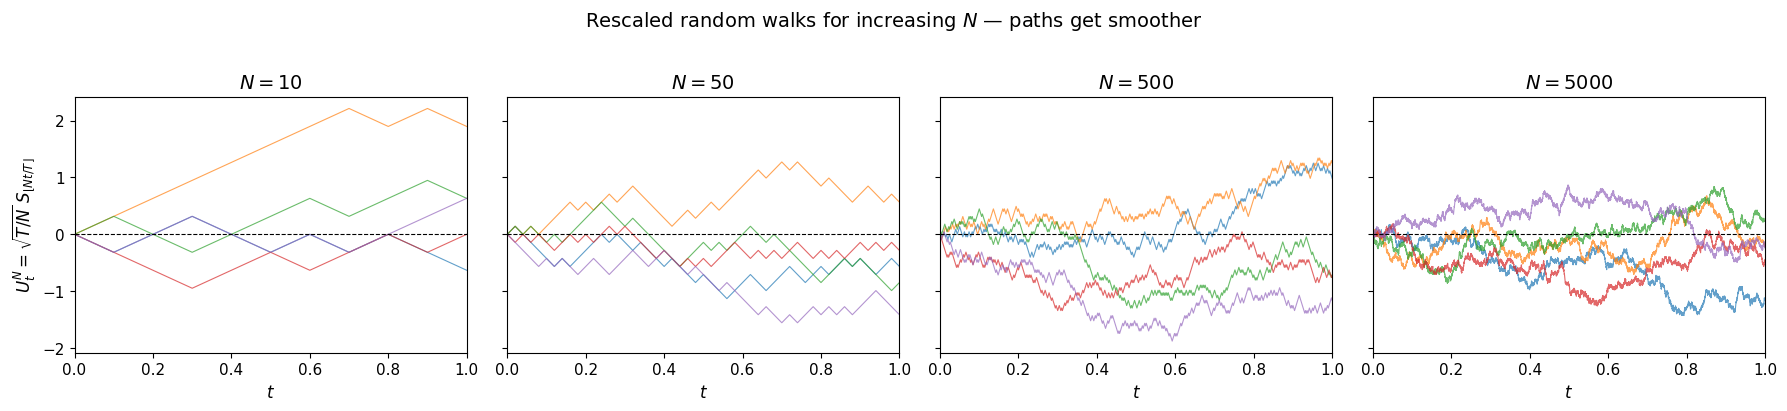

In [2]:
T = 1.0
Ns = [10, 50, 500, 5000]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, N in zip(axes, Ns):
    for _ in range(5):
        steps = rng.choice([-1, 1], size=N)
        walk = np.concatenate([[0], np.cumsum(steps)])
        t = np.linspace(0, T, N + 1)
        ax.plot(t, np.sqrt(T / N) * walk, alpha=0.7, lw=0.8)
    ax.axhline(0, color="black", ls="--", lw=0.8)
    ax.set_title(f"$N = {N}$")
    ax.set_xlabel("$t$")
    ax.set_xlim(0, T)

axes[0].set_ylabel("$U^N_t = \\sqrt{T/N}\\; S_{\\lfloor Nt/T \\rfloor}$")
fig.suptitle("Rescaled random walks for increasing $N$ — paths get smoother", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Why $\sqrt{T/N}$?

If we didn't rescale in space at all, $S_N$ would have standard deviation $\sqrt{N} \to \infty$. If we divided by $N$, the LLN kicks in and everything collapses to zero. The choice $\sqrt{T/N}$ is the *only* scaling that preserves non-trivial fluctuations — it keeps $\text{Var}(\sqrt{T/N}\, S_N) = T$ for all $N$.

This is the same $\sqrt{N}$ that appears in the CLT, and indeed Donsker's theorem is a **functional** (process-level) extension of the CLT.

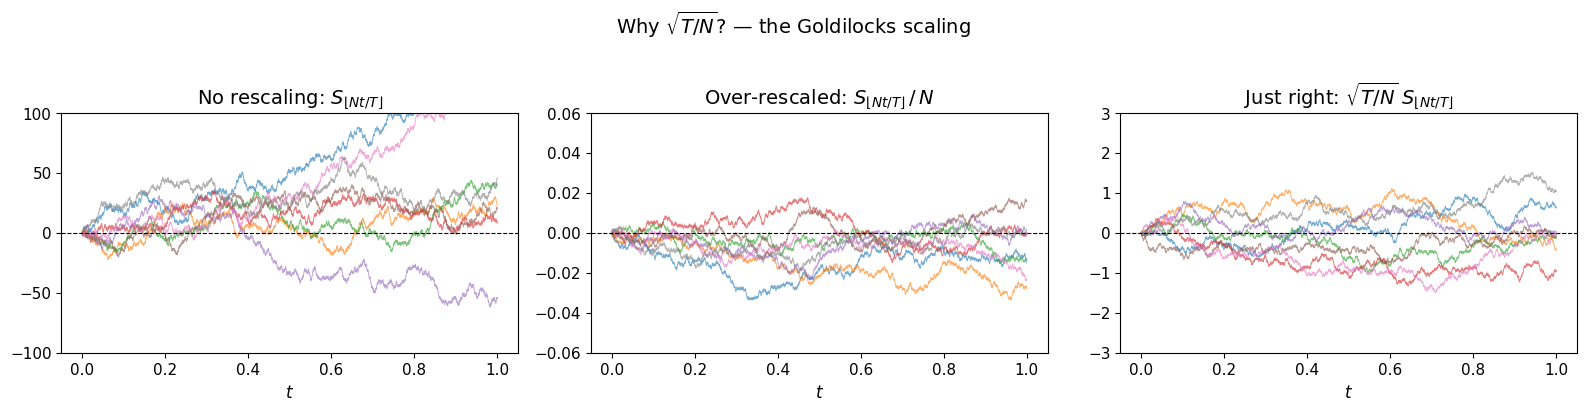

In [3]:
# Demonstrate the three scalings: no rescaling, 1/N, sqrt(T/N)
T = 1.0
N = 2000
n_paths = 8

scalings = [
    ("No rescaling: $S_{\\lfloor Nt/T \\rfloor}$",                     lambda walk, N: walk,                       (-100, 100)),
    ("Over-rescaled: $S_{\\lfloor Nt/T \\rfloor}\\,/\\,N$",            lambda walk, N: walk / N,                   (-0.06, 0.06)),
    ("Just right: $\\sqrt{T/N}\\; S_{\\lfloor Nt/T \\rfloor}$",        lambda walk, N: np.sqrt(T / N) * walk,      (-3, 3)),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
t = np.linspace(0, T, N + 1)

for ax, (title, scaler, ylim) in zip(axes, scalings):
    for _ in range(n_paths):
        steps = rng.choice([-1, 1], size=N)
        walk = np.concatenate([[0], np.cumsum(steps)]).astype(float)
        ax.plot(t, scaler(walk, N), alpha=0.6, lw=0.7)
    ax.axhline(0, color="black", ls="--", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("$t$")
    ax.set_ylim(ylim)

fig.suptitle("Why $\\sqrt{T/N}$? — the Goldilocks scaling", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Part 3: Donsker's Theorem

**Theorem (Donsker, 1951).** Let $X_1, X_2, \ldots$ be i.i.d. with $\mathbb{E}[X_i] = 0$ and $\text{Var}(X_i) = 1$. Define the rescaled, linearly interpolated process on $[0, T]$:

$$U_{k\frac{T}{N}} = \sqrt{\frac{T}{N}}\, S_k, \qquad k = 0, 1, \ldots, N,$$

with linear interpolation between grid points to obtain $U^N_t$.

Then $U^N \xrightarrow{d} W$ in $C[0,T]$, where $W$ is a standard **Brownian motion** (Wiener process).

This is a **functional CLT**: the entire *path* converges in distribution, not just the value at a single time point.

### What is Brownian motion?

A stochastic process $\{W(t)\}_{t \ge 0}$ is a standard Brownian motion if:

1. $W(0) = 0$
2. **Independent increments:** $W(t) - W(s)$ is independent of $\{W(u) : u \le s\}$ for $s < t$
3. **Gaussian increments:** $W(t) - W(s) \sim \mathcal{N}(0, t - s)$
4. **Continuous paths:** $t \mapsto W(t)$ is continuous (a.s.)

Let's verify each of these properties emerges from our rescaled random walk $U^N_t$.

## 3.1 Checking Gaussian increments

If Donsker's theorem holds, $U^N_t$ should be approximately $\mathcal{N}(0, t)$ for large $N$. Let's fix $t = 0.5$ and look at the empirical distribution of $U^N_{0.5} = \sqrt{T/N}\, S_{\lfloor N/2 \rfloor}$ across many simulations.

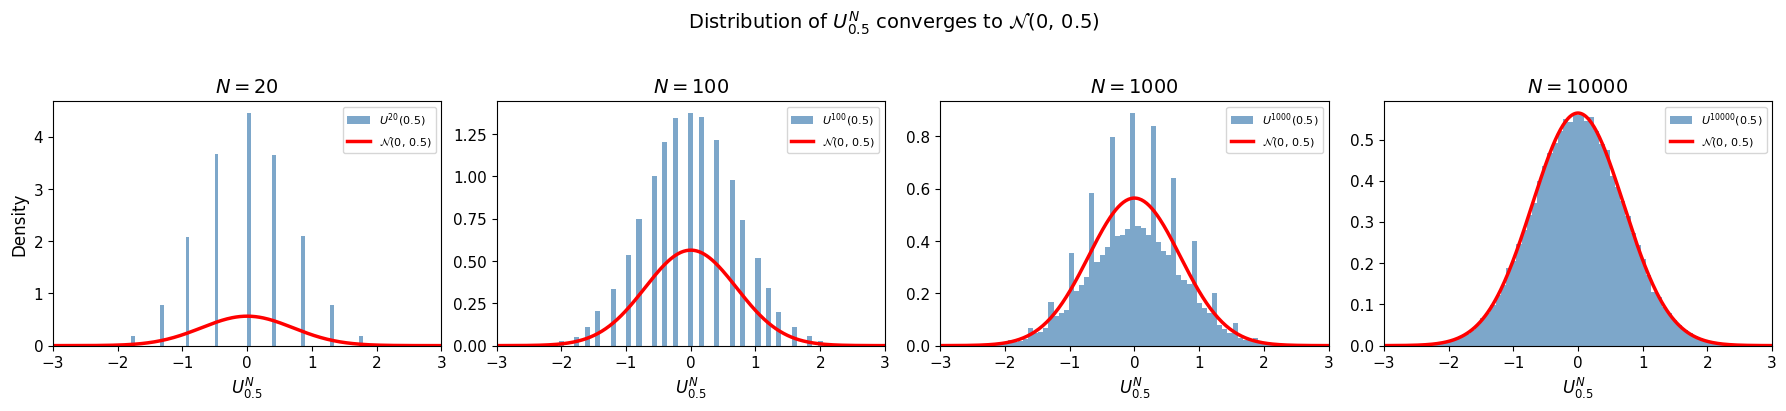

In [4]:
T = 1.0
N_sim = 100_000
t_fixed = 0.5
Ns = [20, 100, 1000, 10000]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, N in zip(axes, Ns):
    half_N = int(N * t_fixed)
    # Each simulation: sqrt(T/N) * sum of half_N Rademacher ±1 steps
    walks_at_t = np.sqrt(T / N) * rng.choice([-1, 1], size=(N_sim, half_N)).sum(axis=1)

    ax.hist(walks_at_t, bins=80, density=True, alpha=0.7, color="steelblue",
            label=f"$U^{{{N}}}(0.5)$")

    # Theoretical N(0, t) = N(0, 0.5)
    x = np.linspace(-3, 3, 300)
    ax.plot(x, stats.norm.pdf(x, 0, np.sqrt(t_fixed)), "r-", lw=2.5,
            label="$\\mathcal{N}(0,\\, 0.5)$")

    ax.set_title(f"$N = {N}$")
    ax.set_xlabel("$U^N_{0.5}$")
    ax.legend(fontsize=8)
    ax.set_xlim(-3, 3)

axes[0].set_ylabel("Density")
fig.suptitle("Distribution of $U^N_{0.5}$ converges to $\\mathcal{N}(0,\\, 0.5)$",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.2 Checking the full marginal distributions — multiple time points

Brownian motion requires $W(t) \sim \mathcal{N}(0, t)$ for *every* $t$, not just $t = 0.5$. Let's check several time points at once: we simulate many rescaled walks $U^N_t$ and compare the empirical variance of $U^N_t$ against the theoretical $\text{Var}(W(t)) = t$.

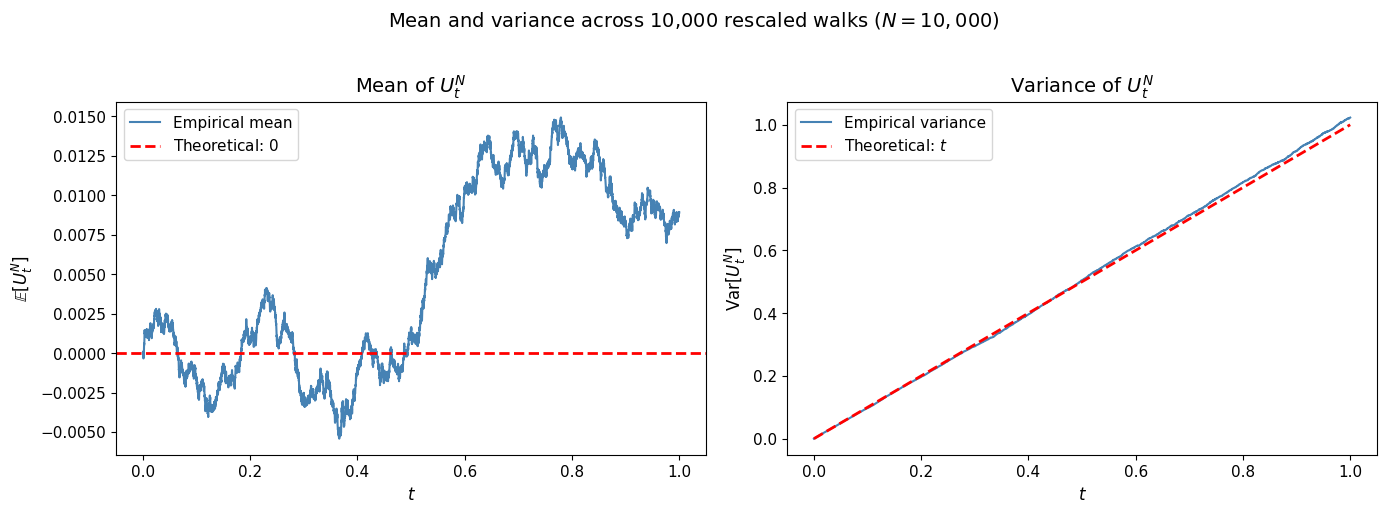

In [5]:
T = 1.0
N = 10_000
N_sim = 10_000

# Simulate N_sim rescaled random walks on [0, T]
steps = rng.choice([-1, 1], size=(N_sim, N))
walks = np.sqrt(T / N) * np.concatenate([np.zeros((N_sim, 1)), np.cumsum(steps, axis=1)], axis=1)

t = np.linspace(0, T, N + 1)
empirical_mean = walks.mean(axis=0)
empirical_var = walks.var(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean
axes[0].plot(t, empirical_mean, color="steelblue", lw=1.5, label="Empirical mean")
axes[0].axhline(0, color="red", ls="--", lw=2, label="Theoretical: $0$")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$\\mathbb{E}[U^N_t]$")
axes[0].set_title("Mean of $U^N_t$")
axes[0].legend()

# Variance
axes[1].plot(t, empirical_var, color="steelblue", lw=1.5, label="Empirical variance")
axes[1].plot(t, t, color="red", ls="--", lw=2, label="Theoretical: $t$")
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("$\\text{Var}[U^N_t]$")
axes[1].set_title("Variance of $U^N_t$")
axes[1].legend()

fig.suptitle(f"Mean and variance across {N_sim:,} rescaled walks ($N = {N:,}$)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.3 Checking the covariance structure

For Brownian motion, $\text{Cov}(W(s), W(t)) = \min(s, t)$. This is a distinctive fingerprint — let's estimate the full covariance matrix from our simulated rescaled walks $U^N_t$ and compare.

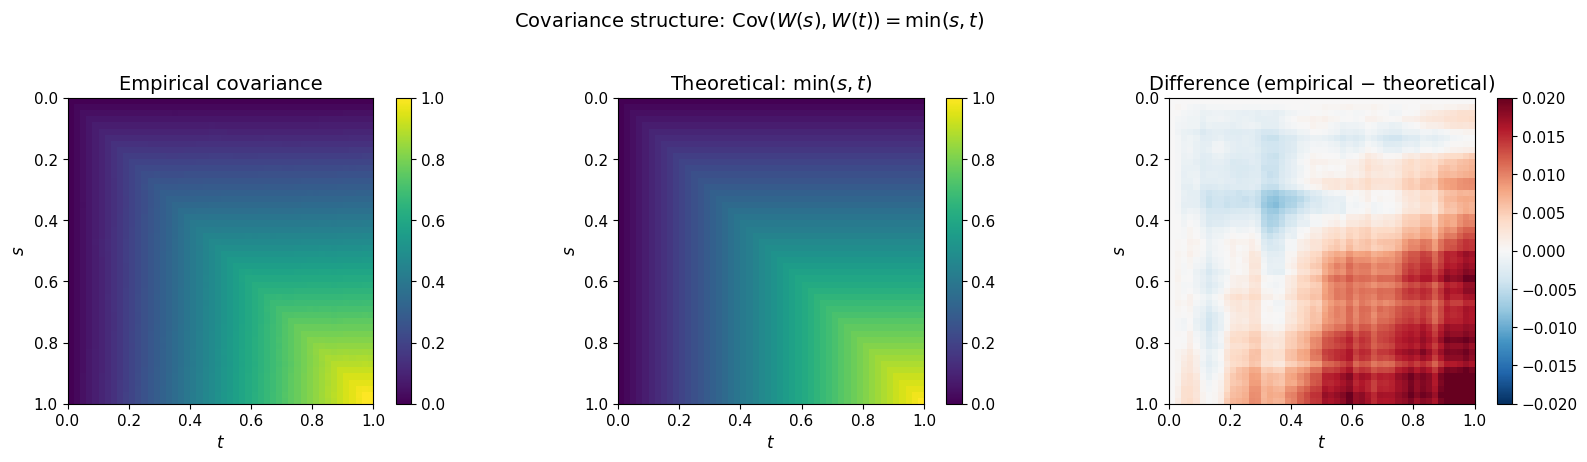

In [6]:
# Use the walks from the previous cell, subsampled at 50 time points for a clear heatmap
n_pts = 50
idx = np.linspace(0, N, n_pts, dtype=int)
t_sub = t[idx]
walks_sub = walks[:, idx]

empirical_cov = np.cov(walks_sub, rowvar=False)

# Theoretical: Cov(W(s), W(t)) = min(s, t)
theoretical_cov = np.minimum.outer(t_sub, t_sub)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

vmin, vmax = 0, 1
im0 = axes[0].imshow(empirical_cov, extent=[0,1,1,0], vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title("Empirical covariance")
axes[0].set_xlabel("$t$"); axes[0].set_ylabel("$s$")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(theoretical_cov, extent=[0,1,1,0], vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title("Theoretical: $\\min(s,t)$")
axes[1].set_xlabel("$t$"); axes[1].set_ylabel("$s$")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

diff = empirical_cov - theoretical_cov
im2 = axes[2].imshow(diff, extent=[0,1,1,0], cmap="RdBu_r", vmin=-0.02, vmax=0.02)
axes[2].set_title("Difference (empirical $-$ theoretical)")
axes[2].set_xlabel("$t$"); axes[2].set_ylabel("$s$")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

fig.suptitle("Covariance structure: $\\text{Cov}(W(s), W(t)) = \\min(s,t)$", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.4 Checking independent increments

For Brownian motion, the increment $W(t_2) - W(t_1)$ should be independent of $W(t_1) - W(t_0)$ when $t_0 < t_1 < t_2$. Let's check this by computing the correlation between non-overlapping increments of $U^N_t$ across our simulations.

Max absolute off-diagonal correlation: 0.0184
(Expected order: ~1/sqrt(10000) ≈ 0.0100)


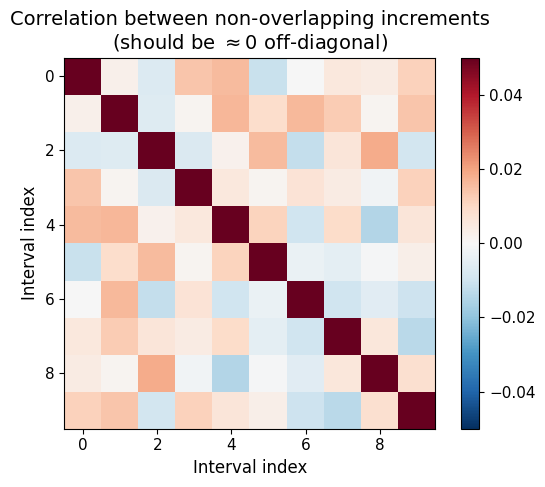

In [7]:
# Partition [0, T] into 10 equal intervals and compute increments
n_intervals = 10
boundaries = np.linspace(0, N, n_intervals + 1, dtype=int)

increments = np.column_stack([
    walks[:, boundaries[i+1]] - walks[:, boundaries[i]]
    for i in range(n_intervals)
])

# Correlation matrix of increments — should be close to identity
corr_matrix = np.corrcoef(increments, rowvar=False)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-0.05, vmax=0.05)
ax.set_title("Correlation between non-overlapping increments\n(should be $\\approx 0$ off-diagonal)")
ax.set_xlabel("Interval index")
ax.set_ylabel("Interval index")
plt.colorbar(im, ax=ax, fraction=0.046)

# Print the max off-diagonal correlation
mask = ~np.eye(n_intervals, dtype=bool)
print(f"Max absolute off-diagonal correlation: {np.abs(corr_matrix[mask]).max():.4f}")
print(f"(Expected order: ~1/sqrt({N_sim}) ≈ {1/np.sqrt(N_sim):.4f})")

plt.tight_layout()
plt.show()

---
# Part 4: Universality — Beyond Coin Flips

The power of Donsker's theorem is that the step distribution **doesn't matter**, as long as $\mathbb{E}[X_i] = 0$ and $\text{Var}(X_i) = 1$. We can replace Rademacher $\pm 1$ steps with *any* centred, unit-variance distribution and still get Brownian motion in the limit.

Let's demonstrate with three very different step distributions:
- **Rademacher** ($\pm 1$, the classic)
- **Standard normal** ($\mathcal{N}(0, 1)$)
- **Centred exponential** ($\text{Exp}(1) - 1$, skewed, variance 1)

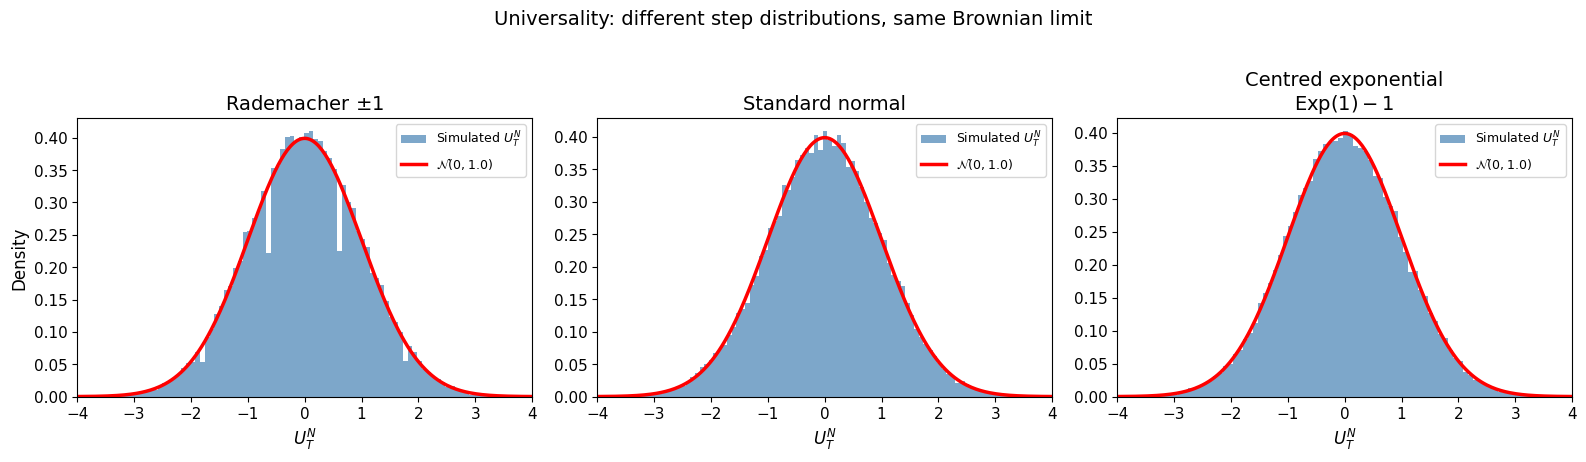

In [8]:
T = 1.0
N = 5000
N_sim = 50_000

step_distributions = [
    ("Rademacher $\\pm 1$",
     lambda: rng.choice([-1, 1], size=(N_sim, N)).astype(float)),
    ("Standard normal",
     lambda: rng.standard_normal(size=(N_sim, N))),
    ("Centred exponential\n$\\text{Exp}(1) - 1$",
     lambda: rng.exponential(1.0, size=(N_sim, N)) - 1.0),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, sampler) in zip(axes, step_distributions):
    steps = sampler()
    walks = np.sqrt(T / N) * np.concatenate([np.zeros((N_sim, 1)), np.cumsum(steps, axis=1)], axis=1)

    # Check U^N_T ~ N(0, T)
    U_T = walks[:, -1]
    ax.hist(U_T, bins=100, density=True, alpha=0.7, color="steelblue",
            label=f"Simulated $U^N_T$")

    x = np.linspace(-4, 4, 300)
    ax.plot(x, stats.norm.pdf(x, 0, np.sqrt(T)), "r-", lw=2.5,
            label=f"$\\mathcal{{N}}(0, {T})$")

    ax.set_title(name)
    ax.set_xlabel("$U^N_T$")
    ax.legend(fontsize=9)
    ax.set_xlim(-4, 4)

axes[0].set_ylabel("Density")
fig.suptitle("Universality: different step distributions, same Brownian limit",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4.1 Visual comparison of paths — all look like Brownian motion

Let's plot a single rescaled path from each step distribution. Despite the very different microscopic dynamics, the macroscopic paths are indistinguishable.

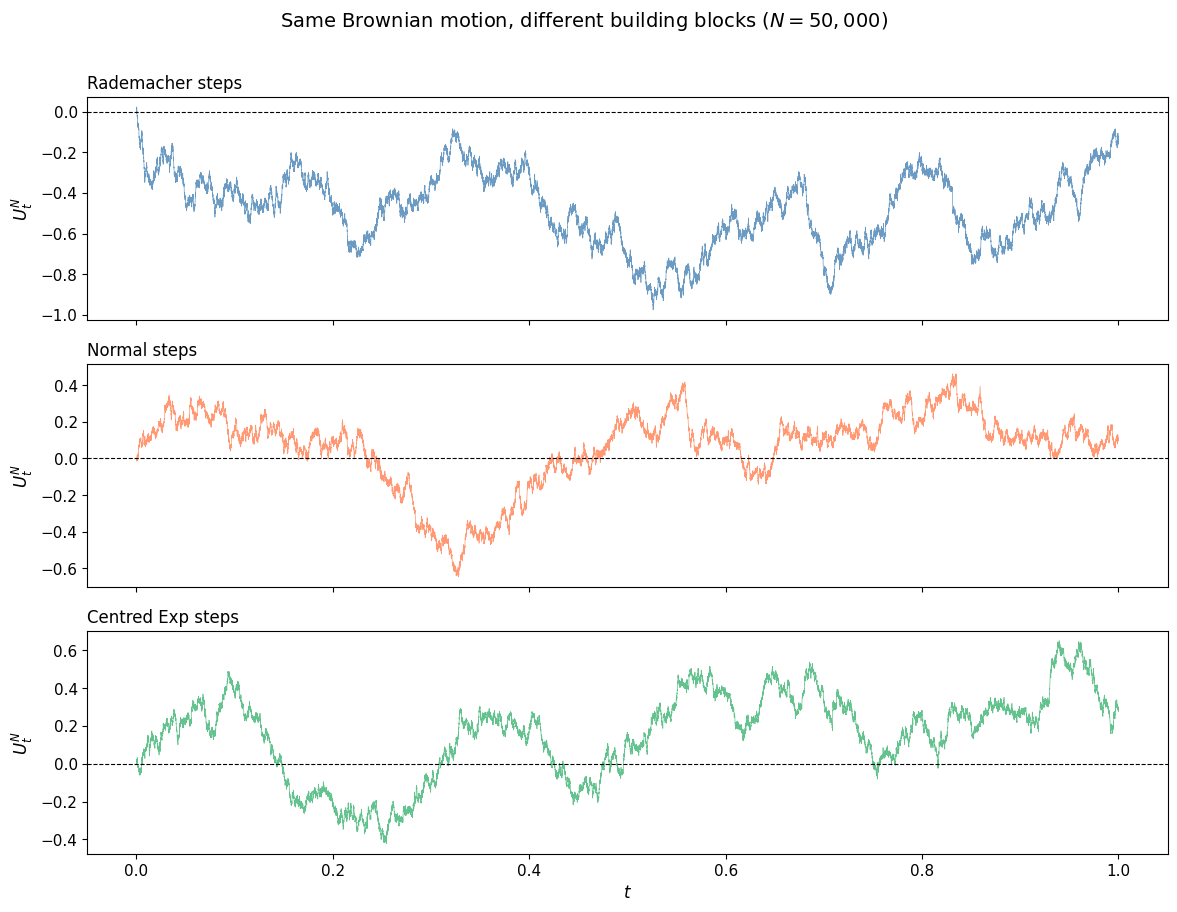

In [9]:
T = 1.0
N = 50_000
t = np.linspace(0, T, N + 1)

path_configs = [
    ("Rademacher steps",        rng.choice([-1, 1], size=N).astype(float), "steelblue"),
    ("Normal steps",            rng.standard_normal(N),                     "coral"),
    ("Centred Exp steps",       rng.exponential(1.0, size=N) - 1.0,        "mediumseagreen"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, (name, steps, color) in zip(axes, path_configs):
    walk = np.sqrt(T / N) * np.concatenate([[0], np.cumsum(steps)])
    ax.plot(t, walk, color=color, lw=0.5, alpha=0.8)
    ax.axhline(0, color="black", ls="--", lw=0.8)
    ax.set_ylabel("$U^N_t$")
    ax.set_title(name, loc="left", fontsize=12)

axes[-1].set_xlabel("$t$")
fig.suptitle(f"Same Brownian motion, different building blocks ($N = {N:,}$)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
# Key Takeaways

| Property | Random walk $S_k$ | Rescaled $U^N_t = \sqrt{T/N}\, S_{\lfloor Nt/T\rfloor}$ | Brownian motion $W(t)$ |
|---|---|---|---|
| Time | Discrete: $k = 0, 1, 2, \ldots$ | Continuous: $t \in [0,T]$ | Continuous: $t \ge 0$ |
| Space | Integer lattice $\mathbb{Z}$ | $\mathbb{R}$ (grid spacing $\sqrt{T/N}$) | $\mathbb{R}$ |
| Paths | Piecewise constant (jumps of $\pm 1$) | Piecewise linear | Continuous, nowhere differentiable |
| Variance at time $t$ | $\lfloor Nt/T \rfloor \approx Nt/T$ | $\frac{T}{N}\lfloor Nt/T \rfloor \approx t$ | Exactly $t$ |
| Increment distribution | Discrete ($\pm 1$) | Approx. Gaussian (by CLT) | Exactly Gaussian |
